In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ===================== CONFIG =====================
DATASET_PATH = r"specify you're own dataset's" #vishnu

RUNS_DIR = r"specify you're output directory path/runs/yolo_v8n"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_TYPE = "yolov8n.pt"
EPOCHS = 50
IMG_SIZE = 224
BATCH = 32
DEVICE = 0  # GPU

os.makedirs(RUNS_DIR, exist_ok=True)

# ===================== LOAD MODEL =====================
model = YOLO(MODEL_TYPE)

# ===================== TRAIN =====================
print("\n🚀 Starting YOLOv8 Training...\n")

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    patience=20,
    project=RUNS_DIR,
    name="asl_yolov8",
    exist_ok=True,
    plots=True,
    save=True,
    verbose=True
)

print("\n✅ Training Finished!\n")

# ===================== VALIDATION =====================
metrics = model.val()

print("\n📊 FINAL METRICS =====================")
print(f"Precision     : {metrics.box.mp:.4f}")
print(f"Recall        : {metrics.box.mr:.4f}")
print(f"mAP50         : {metrics.box.map50:.4f}")
print(f"mAP50-95      : {metrics.box.map:.4f}")
print("======================================\n")

# ===================== SAVE METRICS =====================
metrics_dict = {
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "mAP50": float(metrics.box.map50),
    "mAP50-95": float(metrics.box.map)
}

metrics_path = os.path.join(RUNS_DIR, "asl_yolov8", "metrics_summary.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

# ===================== LOAD RESULTS CSV =====================
results_csv = os.path.join(RUNS_DIR, "asl_yolov8", "results.csv")

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)

    print("\n📈 Showing Training Graphs...\n")

    # -------- Loss Plot --------
    plt.figure()
    plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
    plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
    plt.legend()
    plt.title("Box Loss")
    plt.show()

    # -------- mAP Plot --------
    plt.figure()
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
    plt.legend()
    plt.title("mAP")
    plt.show()

    # -------- Precision Recall --------
    plt.figure()
    plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
    plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
    plt.legend()
    plt.title("Precision & Recall")
    plt.show()

# ===================== SHOW CONFUSION MATRIX =====================
confusion_path = os.path.join(RUNS_DIR, "asl_yolov8", "confusion_matrix.png")

if os.path.exists(confusion_path):
    img = plt.imread(confusion_path)
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix")
    plt.show()

# ===================== SHOW PR & F1 CURVES =====================
for curve in ["PR_curve.png", "F1_curve.png"]:
    curve_path = os.path.join(RUNS_DIR, "asl_yolov8", curve)
    if os.path.exists(curve_path):
        img = plt.imread(curve_path)
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(curve.replace(".png",""))
        plt.show()

print("\n🎯 All graphs displayed successfully!")
print(f"\n📁 Everything saved in: {os.path.join(RUNS_DIR, 'asl_yolov8n')}")


🚀 Starting YOLOv8 Training...

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Projects\Capstone Project\Vision based hand sign detection & classification usig DL models\datasets\custom\Raw Pixel , Landmarks & Yolo\ASL Yolo Dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kob

<Figure size 640x480 with 1 Axes>

<Figure size 640x480 with 1 Axes>

<Figure size 640x480 with 1 Axes>

<Figure size 1000x800 with 1 Axes>


🎯 All graphs displayed successfully!

📁 Everything saved in: D:\Projects\Capstone Project\Vision based hand sign detection & classification usig DL models\runs\yolov8\asl_yolov8n


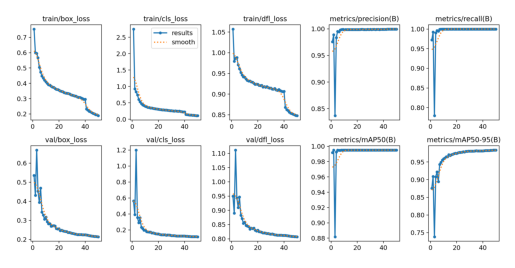

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

BASE_DIR = os.getcwd()

RUNS_DIR = os.path.join(BASE_DIR, "..", "runs", "yolo_v8n")
img_path = os.path.join(RUNS_DIR, "asl_yolov8", "results.png")

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()